# Sentiment Analysis using PyTorch and NLTK

End-to-end deep learning pipeline for **Mulit-class(3) Sentiment Analysis** (`Negative`, `Neutral`, `Positive`) on Twitter dataset.

### Pipeline Architecture:
1. **Imports & Environment Setup**: PyTorch, NLTK, Pandas, NumPy, and random seeds.
2. **Data Loading & Cleaning**: Reading `train.csv` and `test.csv` from `Sentiment_Dataset.zip` with `latin1` encoding.
3. **Text Preprocessing with NLTK**: Lowercasing, noise/URL removal, NLTK tokenization (`RegexpTokenizer`), and lemmatization (`WordNetLemmatizer`).
4. **Build Vocabulary**: Custom `Vocabulary` builder class mapping tokens to indices
5. **PyTorch custom Dataset**: `SentimentDataset` class with `DataLoader` batching.
6. **PyTorch Model Architecture**: Bidirectional LSTM (`SentimentBiLSTM`) neural network.
7. **Training Loop & Validation**: Multi-epoch model training with Cross-Entropy Loss and Adam optimizer.
8. **Save & Load Model**: Save the model for reusability. Load the saved model no need to run the code again and again.
9. **Evaluation & Metrics**: Performance assessment on test set with Classification Report and Confusion Matrix.
10. **Interactive Inference**: Real-time sentiment prediction function `predict_sentiment()` for custom inputs.

## 1. Imports & Environment Setup

In [92]:
from pathlib import Path

import re
from zipfile import ZipFile
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import nltk
from nltk.tokenize import RegexpTokenizer
from nltk.stem import WordNetLemmatizer

# random seed
SEED = 632
torch.manual_seed(SEED)
if torch.cuda.is_available:
    torch.cuda.manual_seed_all(SEED)

# device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# filter warnings
import warnings
warnings.filterwarnings(action='ignore', message='FutureWarning')

Using device: cpu


In [52]:
# Download necessary NLTK corpora
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
print("NLTK resources checked and downloaded successfully!")

NLTK resources checked and downloaded successfully!


## 2. Data Loading & Cleaning

In [53]:
with ZipFile('Sentiment_Dataset.zip', 'r') as z:
    # read train dataset
    with z.open('train.csv', 'r') as f:
        train_df = pd.read_csv(f, encoding='latin1')
    # read test dataset
    with z.open('test.csv', 'r') as f:
        test_df = pd.read_csv(f, encoding='latin1')
        
# getting error due to encoding mismatch so using latin1

In [54]:
# shape of datasets
print(f'Shape of raw train dataset: {train_df.shape}')
print(f'Shape of raw test dataset: {test_df.shape}')

Shape of raw train dataset: (27481, 10)
Shape of raw test dataset: (4815, 9)


In [55]:
train_df.head()

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


We are already given refined text as feature *selected_text* but I will create my own refined text

required colums are text and labels

In [56]:
# check for null values and drop them
print(f'Shape of train dataset before droping: {train_df.shape}')
print(f'Shape of test dataset before droping: {test_df.shape}')

train_df = train_df.dropna(axis=0, subset=['text', 'sentiment'])
test_df = test_df.dropna(axis=0, subset=['text', 'sentiment'])

print(f'Shape of train dataset after droping: {train_df.shape}')
print(f'Shape of test dataset after droping: {test_df.shape}')

Shape of train dataset before droping: (27481, 10)
Shape of test dataset before droping: (4815, 9)
Shape of train dataset after droping: (27480, 10)
Shape of test dataset after droping: (3534, 9)


In [57]:
# mapping the sentiments with numerical labels
label2id_mapper = {'negative': 0, 'neutral':1, 'positive':2}
id2label_mapper = {0:'negative', 1:'neutral', 2: 'positive'}

train_df['id'] = train_df['sentiment'].map(label2id_mapper)
test_df['id'] = test_df['sentiment'].map(label2id_mapper)

train_df[['text', 'sentiment', 'id']].head()

,text,sentiment,id
0,"I`d have responded, if I were going",neutral,1
1,Sooo SAD I will miss you here in San Diego!!!,negative,0
2,my boss is bullying me...,negative,0
3,what interview! leave me alone,negative,0
4,"Sons of ****, why couldn`t they put them on t...",negative,0


In [58]:
# distribution of setiments
print('Distribution(count) of sentiments in Train Dataset')
print(train_df['sentiment'].value_counts())

print('\nDistribution(percentage) of sentiments in Train Dataset')
print(f'{(train_df['sentiment'].value_counts()/train_df.shape[0])*100}')

Distribution(count) of sentiments in Train Dataset
sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64

Distribution(percentage) of sentiments in Train Dataset
sentiment
neutral     40.454876
positive    31.229985
negative    28.315138
Name: count, dtype: float64


## 3. Text Preprocessing using NLTK

In [59]:
tokenizer = RegexpTokenizer(r'\w+')
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if not isinstance(text, str):
        print('not string type')
        return []

    # lowercase the text
    text = text.lower()
    
    # remove urls and user mentions
    text = re.sub(r'https?://\S+|www.\S+|@\w+', '', text)
    
    # tokenize the text
    tokens = tokenizer.tokenize(text)
    
    # lemmatize and not filter stopwords
    clean_tokens = [lemmatizer.lemmatize(token) for token in tokens if len(token) > 1 and not token.isdigit()]
    
    return clean_tokens

In [60]:
print(preprocess_text('Hello how are you this is @PrashantKumar check this url https://sjiaojdja. Wanna play a tag game.'))

['hello', 'how', 'are', 'you', 'this', 'is', 'check', 'this', 'url', 'wanna', 'play', 'tag', 'game']


## 4. Build Vocabulary

In [61]:
class Vocabulary():
    def __init__(self, min_freq=2):
        self.min_freq = min_freq
        self.stoi = {'<pad>':0, '<unk>':1}
        self.itos = {0:'<pad>', 1:'<unk>'}
        self.freq = {}
        
    def build_vocab(self, tokenized_text):
        for tokens in tokenized_text:
            for token in tokens:
                self.freq[token] = self.freq.get(token, 0) + 1

        idx = 2
        for token, count in self.freq.items():
            if count >= self.min_freq:
                self.stoi[token] = idx
                self.itos[idx] = token
                idx+=1

    def tokens2nums(self, tokens):
        return [self.stoi.get(token, self.stoi['<unk>']) for token in tokens]

    def __len__(self):
        return len(self.stoi)

In [62]:
print('Preprocessing text tokens....')
train_df['clean_tokens'] = train_df['text'].apply(preprocess_text)
test_df['clean_tokens'] = test_df['text'].apply(preprocess_text)

Preprocessing text tokens....


In [63]:
train_df[['text', 'sentiment', 'id', 'clean_tokens']].head()

,text,sentiment,id,clean_tokens
0,"I`d have responded, if I were going",neutral,1,"[have, responded, if, were, going]"
1,Sooo SAD I will miss you here in San Diego!!!,negative,0,"[sooo, sad, will, miss, you, here, in, san, di..."
2,my boss is bullying me...,negative,0,"[my, bos, is, bullying, me]"
3,what interview! leave me alone,negative,0,"[what, interview, leave, me, alone]"
4,"Sons of ****, why couldn`t they put them on t...",negative,0,"[son, of, why, couldn, they, put, them, on, th..."


In [64]:
vocab = Vocabulary(min_freq=2)
vocab.build_vocab(train_df['clean_tokens'])
print(f'Vocabulary created successfully...\nVocabulary size: {len(vocab)} unique tokens')

Vocabulary created successfully...
Vocabulary size: 9341 unique tokens


In [65]:
train_df.reset_index(inplace=True)
test_df.reset_index(inplace=True)

## 5. Custom SentimentDataset

In [66]:
class SentimentDataset(Dataset):
    def __init__(self, tokenized_texts, labels, vocab, max_len=40):
        self.tokenized_texts = tokenized_texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.tokenized_texts)

    def __getitem__(self, idx):
        tokens = self.tokenized_texts[idx]
        numericalized_tokens = self.vocab.tokens2nums(tokens)

        # pad or turncate
        if len(numericalized_tokens) < self.max_len:
            padded = numericalized_tokens + [self.vocab.stoi['<pad>']]*(self.max_len - len(numericalized_tokens)) 
        else:
            padded = numericalized_tokens[:self.max_len]

        return torch.tensor(padded, dtype=torch.int64), torch.tensor(self.labels[idx], dtype=torch.int64)

In [67]:
MAX_LEN = 40
BATCH_SIZE = 64

train_datset = SentimentDataset(train_df['clean_tokens'].tolist(), labels=train_df['id'], vocab=vocab, max_len=MAX_LEN)
test_datset = SentimentDataset(test_df['clean_tokens'].tolist(), labels=test_df['id'], vocab=vocab, max_len=MAX_LEN)

In [68]:
train_loader = DataLoader(train_datset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_datset, batch_size=BATCH_SIZE, shuffle=True)

In [69]:
for i, (x, y) in enumerate(train_loader):
    if i ==5:
        break
    print(x, y)

tensor([[ 193,   68,  823,  ...,    0,    0,    0],
        [ 527,  287, 5893,  ...,    0,    0,    0],
        [1772,  569,   38,  ...,    0,    0,    0],
        ...,
        [ 217,  924,   12,  ...,    0,    0,    0],
        [ 748,   31,  645,  ...,    0,    0,    0],
        [ 416,   31, 4449,  ...,    0,    0,    0]]) tensor([2, 2, 2, 2, 0, 0, 0, 1, 2, 1, 0, 1, 0, 0, 2, 1, 1, 0, 1, 1, 0, 1, 0, 1,
        0, 1, 1, 2, 1, 2, 1, 0, 1, 0, 1, 2, 1, 1, 0, 1, 1, 2, 2, 1, 1, 2, 1, 0,
        1, 2, 0, 1, 1, 0, 2, 2, 1, 0, 1, 0, 2, 1, 0, 0])
tensor([[2341,   52, 5205,  ...,    0,    0,    0],
        [5955,  253,  114,  ...,    0,    0,    0],
        [ 160,  218,    1,  ...,    0,    0,    0],
        ...,
        [ 121,  125,    1,  ...,    0,    0,    0],
        [1992,  739,  121,  ...,    0,    0,    0],
        [ 266,  477,  478,  ...,    0,    0,    0]]) tensor([1, 2, 0, 1, 0, 0, 1, 0, 0, 2, 0, 2, 0, 0, 1, 2, 1, 1, 2, 1, 1, 1, 2, 1,
        1, 1, 1, 2, 0, 0, 2, 2, 0, 1, 1, 2, 2, 0, 2

## 6. Bidirectional LSTM Model

In [70]:
class SentimentBiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, num_layers=2, dropout=0.3):
        super(SentimentBiLSTM, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bias=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, text):
        embedded = self.dropout(self.embedding(text))  # [batch_size, max_len, embed_dim]
        lstm_out, (hidden, cell) = self.lstm(embedded)
        
        # Concatenate forward and backward final hidden state
        hidden_last = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)  # [batch_size, hidden_dim * 2]
        logits = self.fc(self.dropout(hidden_last))
        return logits

In [71]:
# lstmModel hyperparameters
EMBED_DIM = 120
HIDDEN_DIM = 148
OUTPUT_DIM = 3
NUM_LAYERS = 2
DROPOUT = 0.3

In [72]:
lstmModel = SentimentBiLSTM(len(vocab), EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM, NUM_LAYERS, DROPOUT)
lstmModel = lstmModel.to(device) # for gpu
print(lstmModel)

SentimentBiLSTM(
  (embedding): Embedding(9341, 120, padding_idx=0)
  (lstm): LSTM(120, 148, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc): Linear(in_features=296, out_features=3, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


## 7. Model Training & Validation

In [73]:
# other hyperparameters
LEARNING_RATE = 1e-3
EPOTCHS = 5

In [74]:

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(lstmModel.parameters(), lr=LEARNING_RATE)

In [75]:
def train_model(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x_batch, y_batch in dataloader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        logits = model(x_batch) # logits - the raw, unnormalized outputs from the final layer of a neural network before any activation function.
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * len(y_batch)
        preds = torch.argmax(logits, dim=1) # choose the id which highest probability
        
        correct += (preds == y_batch).sum().item()
        total += len(y_batch)
        
    return total_loss / total, correct / total  # average loss, averge correct answers

In [76]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    
    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            logits = model(x_batch)
            
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * len(y_batch)
            
            preds = torch.argmax(logits, dim=1)
            
            correct += (preds == y_batch).sum().item()
            total += len(y_batch)
            
    return total_loss/ total, correct / total

In [77]:
print('Training model....')
for epoch in range(1, EPOTCHS+1):
    
    train_loss, train_accuracy = train_model(lstmModel, train_loader, criterion, optimizer, device)
    
    test_loss, test_accuracy = evaluate_model(lstmModel, test_loader, criterion, device)
    
    print(f'Epoch [{epoch}/{EPOTCHS}] | Train Loss: {train_loss:.3f} | Train Acc: {train_accuracy*100:.3f}% | Test Loss: {test_loss:.3f} | Test Acc: {test_accuracy*100:.3f}%')

Training model....
Epoch [1/5] | Train Loss: 0.930 | Train Acc: 55.291% | Test Loss: 0.795 | Test Acc: 64.375%
Epoch [2/5] | Train Loss: 0.779 | Train Acc: 65.378% | Test Loss: 0.716 | Test Acc: 69.128%
Epoch [3/5] | Train Loss: 0.704 | Train Acc: 69.803% | Test Loss: 0.681 | Test Acc: 71.477%
Epoch [4/5] | Train Loss: 0.646 | Train Acc: 72.937% | Test Loss: 0.656 | Test Acc: 72.439%
Epoch [5/5] | Train Loss: 0.603 | Train Acc: 74.960% | Test Loss: 0.642 | Test Acc: 73.260%


```text
Training model....
Epoch [1/5] | Train Loss: 0.934 | Train Acc: 55.109% | Test Loss: 0.790 | Test Acc: 65.931%
Epoch [2/5] | Train Loss: 0.788 | Train Acc: 65.506% | Test Loss: 0.719 | Test Acc: 68.930%
Epoch [3/5] | Train Loss: 0.706 | Train Acc: 69.651% | Test Loss: 0.686 | Test Acc: 71.024%
Epoch [4/5] | Train Loss: 0.645 | Train Acc: 73.002% | Test Loss: 0.676 | Test Acc: 72.524%
Epoch [5/5] | Train Loss: 0.606 | Train Acc: 75.149% | Test Loss: 0.658 | Test Acc: 73.316%
```

**Note**: The $CrossEntropyLoss()$ fucntion takes input as torch.long or int64 datatype only

## Save Model

In [94]:
cur_path = Path.cwd()
model_path = cur_path / 'Saved_Model/Sentiment_Analysis_LSTM_Model.pth'

In [ ]:
print('Saving model....')
torch.save(lstmModel, model_path)
print('Model saved successfully')

Saving model....
Model saved successfully


## Load Model

In [95]:
print('Loading model....')
loaded_model = torch.load(model_path, weights_only=False)
print('Model loaded successfully')
lstmModel = loaded_model

Loading model....
Model loaded successfully


## 8. Model Evaluation & Confusion Matrix

In [96]:
lstmModel.eval()
all_preds = []
all_labels = []

In [97]:
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        logits = lstmModel(x_batch)
        loss = criterion(logits, y_batch)
        
        preds = torch.argmax(logits, dim=1).cpu().numpy()
    
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

In [98]:
target_names = ['negative', 'neutal', 'positive']

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

In [100]:
print('Classification Report:')
print(classification_report(all_labels, all_preds, target_names=target_names))

Classification Report:
              precision    recall  f1-score   support

    negative       0.77      0.66      0.71      1001
      neutal       0.66      0.79      0.72      1430
    positive       0.84      0.74      0.78      1103

    accuracy                           0.73      3534
   macro avg       0.75      0.73      0.74      3534
weighted avg       0.74      0.73      0.73      3534



Text(0.5, 1.0, 'Sentiment Analysis Evaluation Confusion Matrix')

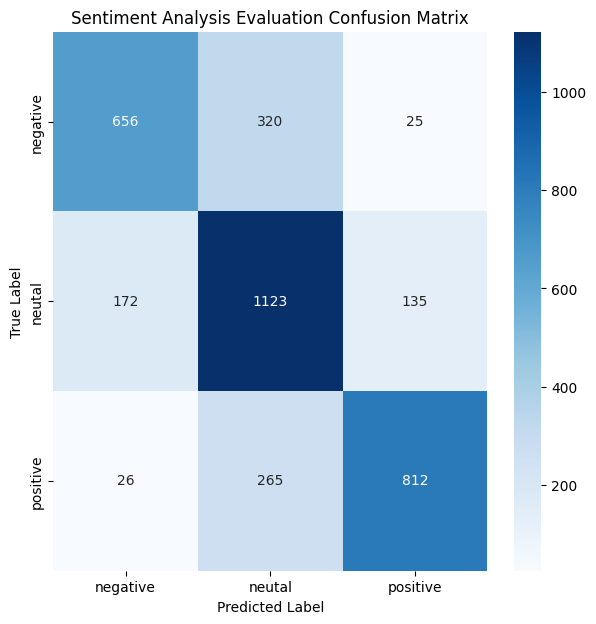

In [101]:
# confusion matrix visual
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Sentiment Analysis Evaluation Confusion Matrix')

## 8. Real-Time Inference Function

In [102]:
def predict_sentiment(text, model, vocab, max_len=30):
    model.eval()
    tokens = preprocess_text(text)
    numericalized = vocab.tokens2nums(tokens)
    
    if len(numericalized) < max_len:
        padded = numericalized + [vocab.stoi['<pad>']] * (max_len - len(numericalized))
    else:
        padded = numericalized[:max_len]
    
    tensor_input = torch.tensor([padded], dtype=torch.long).to(device)
    
    with torch.no_grad():
        logits = model(tensor_input)
        probs = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
        pred_id = int(torch.argmax(logits, dim=1).item())
    
    
    pred_label = id2label_mapper[pred_id]
    
    return {
        'text': text,
        'predicted_sentiment': pred_label,
        'confidence': float(probs[pred_id]),
        'probabilities': {id2label_mapper[i]: round(float(probs[i]), 4) for i in range(3)}
    }


In [103]:
sample_inputs = [
    "I absolutely love this product! Highly recommended.",
    "Extremely disappointed with the service and quality.",
    "The package was delivered today at 2 PM.",
    "This works very good sometimes but sometimes is doesn't so I would recommand if was using this but this is being used by my friend so I don't know what should I say but it's stil fair enough",
    'This pen writes smoothly with consistent ink flow and comfortable grip. The tip is precise without skipping. Durable and reliable for daily use. Highly recommended for anyone seeking quality writing at an affordable price.',
    'This pen writes smoothly with consistent ink flow and comfortable grip. Precise, reliable, and durable. Highly recommended for daily use.',
    'This bottle has character and definitely makes a statement. The lid mechanism is unique, though it takes some getting used to. Quality construction, but at this price point, I expected something more straightforward and low-maintenance. Not worth for money.'
]

In [104]:
for sample in sample_inputs:
    result = predict_sentiment(sample, lstmModel, vocab)
    print(f"\nText: '{result['text']}'")
    print(f"-> Predicted Sentiment: {result['predicted_sentiment'].upper()} (Confidence: {result['confidence']*100:.1f}%)")
    print(f"   Class Probabilities: {result['probabilities']}\n")


Text: 'I absolutely love this product! Highly recommended.'
-> Predicted Sentiment: POSITIVE (Confidence: 93.9%)
   Class Probabilities: {'negative': 0.0082, 'neutral': 0.053, 'positive': 0.9389}


Text: 'Extremely disappointed with the service and quality.'
-> Predicted Sentiment: NEGATIVE (Confidence: 79.6%)
   Class Probabilities: {'negative': 0.7958, 'neutral': 0.1776, 'positive': 0.0265}


Text: 'The package was delivered today at 2 PM.'
-> Predicted Sentiment: NEUTRAL (Confidence: 72.7%)
   Class Probabilities: {'negative': 0.0759, 'neutral': 0.7273, 'positive': 0.1969}


Text: 'This works very good sometimes but sometimes is doesn't so I would recommand if was using this but this is being used by my friend so I don't know what should I say but it's stil fair enough'
-> Predicted Sentiment: NEUTRAL (Confidence: 46.8%)
   Class Probabilities: {'negative': 0.2192, 'neutral': 0.4676, 'positive': 0.3132}


Text: 'This pen writes smoothly with consistent ink flow and comfortable grip

**This model is working good on those words in the dataset as expected if some other words (as per sepecific thing/situation) is give then the model is not predicting right. The solution for this is to have variety to comments/reviews in the dataset.**


- I thought the above one was the only reason I was getting wrong predictions but the second reasons is I removed the stopwords which I shouldn't have because LSTM have the capability to capture sementic meaning.